# Noisy Weights — Varying Noise Analysis

Analyses how the network performs as the noise level increases. Higher noise means greater perturbation to the initial weights. Compares the trained student against the teacher at each noise level, with the correct student (SF at target) shown as a baseline where relevant.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from connectome_snns.utils.reproducibility import load_experiment_config
from connectome_snns.visualization import use_project_style, plot_spike_trains
from connectome_snns.visualization.firing_rate_scatter import plot_firing_rate_scatter
from connectome_snns.analysis import (
    r_squared,
    fluctuation_r_squared,
    firing_rates_from_spikes,
    interleave_spike_trains,
)

use_project_style()

In [ ]:
# Load varying noise results (trained student) and inference baseline (correct student)
varying_noise_config = load_experiment_config("experiment.toml")
inference_config = load_experiment_config("../inference/experiment.toml")

varying_noise_dir = varying_noise_config["output_dir"]
inference_noise_dir = inference_config["output_dir"]

HAS_VARYING_NOISE = varying_noise_dir.exists()

if not HAS_VARYING_NOISE:
    print("SKIPPED: varying-noise data not found at", varying_noise_dir)
else:
    run_dirs = sorted(
        [
            d
            for d in varying_noise_dir.iterdir()
            if d.is_dir() and d.name.startswith("noise-")
        ]
    )
    print(f"Found {len(run_dirs)} trained noise level runs")

    results = []
    for run_dir in run_dirs:
        match = re.search(r"noise-([\d.]+)", run_dir.name)
        if not match:
            continue
        noise_frac = float(match.group(1))

        metrics_path = run_dir / "training_metrics.csv"
        if not metrics_path.exists():
            continue

        df = pd.read_csv(metrics_path)
        final = df.iloc[-1]

        results.append(
            {
                "noise_fraction": noise_frac,
                "final_loss": final["total_loss"],
                "student_fr_exc": final["firing_rate/student_excitatory_mean"],
                "student_fr_inh": final["firing_rate/student_inhibitory_mean"],
                "teacher_fr_exc": final["firing_rate/teacher_excitatory_mean"],
                "teacher_fr_inh": final["firing_rate/teacher_inhibitory_mean"],
                "exc_to_exc": final["scaling_factors/excitatory_to_excitatory_value"],
                "exc_to_inh": final["scaling_factors/excitatory_to_inhibitory_value"],
                "inh_to_exc": final["scaling_factors/inhibitory_to_excitatory_value"],
                "inh_to_inh": final["scaling_factors/inhibitory_to_inhibitory_value"],
                "mitral_to_exc": final["scaling_factors/mitral_to_excitatory_value"],
                "mitral_to_inh": final["scaling_factors/mitral_to_inhibitory_value"],
            }
        )

    results_df = (
        pd.DataFrame(results).sort_values("noise_fraction").reset_index(drop=True)
    )

    # Load inference baseline (for loss/FR comparison plots only)
    HAS_INFERENCE_NOISE = inference_noise_dir.exists()
    if HAS_INFERENCE_NOISE:
        inference_dirs = sorted(
            [
                d
                for d in inference_noise_dir.iterdir()
                if d.is_dir() and d.name.startswith("noise-")
            ]
        )
        print(f"Found {len(inference_dirs)} inference (correct student) runs")

        inference_results = []
        for inf_dir in inference_dirs:
            match = re.search(r"noise-([\d.]+)", inf_dir.name)
            if not match:
                continue
            noise_frac = float(match.group(1))
            metrics_path = inf_dir / "training_metrics.csv"
            if not metrics_path.exists():
                continue
            df = pd.read_csv(metrics_path)
            inference_results.append(
                {
                    "noise_fraction": noise_frac,
                    "inference_loss": df["loss"].iloc[0],
                    "inference_fr_exc": df["firing_rate/student_exc_mean"].iloc[0],
                    "inference_fr_inh": df["firing_rate/student_inh_mean"].iloc[0],
                }
            )

        inference_df = (
            pd.DataFrame(inference_results)
            .sort_values("noise_fraction")
            .reset_index(drop=True)
        )
        print(f"Inference noise levels: {inference_df['noise_fraction'].tolist()}")
    else:
        print("No inference data found")

    print(f"Trained noise levels: {results_df['noise_fraction'].tolist()}")

### Weight Perturbation Visualization

Visualizes how the initial weight noise compares to the original teacher weights at noise levels **0.10** and **0.50**.

In [ ]:
if not HAS_VARYING_NOISE:
    print("SKIPPED: no varying-noise data")
else:
    noise_levels_to_plot = [0.10, 0.40]

    # Teacher network structure from experiment data_inputs
    teacher_network_path = varying_noise_config["data_inputs"][0]
    teacher_data = np.load(teacher_network_path)
    teacher_feedforward_weights = teacher_data["feedforward_weights"]
    teacher_recurrent_weights = teacher_data["recurrent_weights"]
    teacher_feedforward_connectivity = teacher_data["feedforward_connectivity"]
    teacher_recurrent_connectivity = teacher_data["recurrent_connectivity"]
    teacher_cell_type_indices = teacher_data["cell_type_indices"]
    teacher_feedforward_cell_type_indices = teacher_data[
        "feedforward_cell_type_indices"
    ]

    teacher_concatenated_weights = np.concatenate(
        [teacher_feedforward_weights, teacher_recurrent_weights], axis=0
    )
    teacher_concatenated_connectivity = np.concatenate(
        [teacher_feedforward_connectivity, teacher_recurrent_connectivity], axis=0
    )
    teacher_connected_mask = teacher_concatenated_connectivity > 0
    teacher_weights_connected = teacher_concatenated_weights[teacher_connected_mask]

    print(f"Teacher weights: {teacher_concatenated_weights.shape}")
    print(f"Connected synapses: {teacher_connected_mask.sum()}")

    n_ff_cell_types = teacher_feedforward_cell_type_indices.max() + 1
    teacher_concatenated_cell_type_indices = np.concatenate(
        [
            teacher_feedforward_cell_type_indices,
            teacher_cell_type_indices + n_ff_cell_types,
        ]
    )

    noisy_weights_dict = {}
    for noise in noise_levels_to_plot:
        noise_dir = varying_noise_dir / f"noise-{noise:.2f}"
        initial_data = np.load(noise_dir / "initial_state" / "network_structure.npz")
        perturbed_weights = initial_data["feedforward_weights"]
        concatenated_connectivity = initial_data["feedforward_connectivity"]
        concatenated_cell_type_indices = initial_data["feedforward_cell_type_indices"]

        target_sf = np.load(noise_dir / "targets" / "target_scaling_factors.npz")[
            "feedforward_scaling_factors"
        ]

        noisy_weights = perturbed_weights.copy()
        sf_matrix = target_sf[
            concatenated_cell_type_indices[:, None], teacher_cell_type_indices[None, :]
        ]
        noisy_weights *= sf_matrix

        connected_mask = concatenated_connectivity > 0
        noisy_weights_dict[noise] = noisy_weights[connected_mask]
        print(
            f"Noise {noise:.2f}: loaded {len(noisy_weights_dict[noise])} connected weights"
        )

In [ ]:
if not HAS_VARYING_NOISE:
    print("SKIPPED: no varying-noise data")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, noise in zip(axes, noise_levels_to_plot):
        noisy = noisy_weights_dict[noise]

        max_points = 2000
        rng_plot = np.random.default_rng(42)
        # Weight sampling by distance from origin so tails are represented
        dist = np.sqrt(teacher_weights_connected**2 + noisy**2)
        prob = dist / dist.sum()
        idx = rng_plot.choice(
            len(teacher_weights_connected), max_points, replace=False, p=prob
        )

        ax.scatter(teacher_weights_connected[idx], noisy[idx], alpha=0.6, s=1)

        lims = [
            min(0, noisy.min()),
            np.percentile(np.concatenate([teacher_weights_connected, noisy]), 95),
        ]
        ax.plot(lims, lims, "k--", linewidth=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)

        correlation = np.corrcoef(teacher_weights_connected, noisy)[0, 1]
        stats_text = (
            f"Original: \u03bc={teacher_weights_connected.mean():.6f}, \u03c3={teacher_weights_connected.std():.6f}\n"
            f"Noisy:    \u03bc={noisy.mean():.6f}, \u03c3={noisy.std():.6f}\n"
            f"Corr: r={correlation:.4f}"
        )
        ax.text(
            0.05,
            0.95,
            stats_text,
            transform=ax.transAxes,
            verticalalignment="top",
            fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        )
        ax.set_xlabel("Original Weight")
        ax.set_ylabel("Noisy Weight")
        ax.set_title(f"Original vs Noisy Weights (Noise = {noise:.2f})")
        ax.set_aspect("equal")

    plt.tight_layout()
    fig.savefig(varying_noise_dir / "weight_perturbation.svg", bbox_inches="tight")
    plt.show()
    print(f"Saved to {varying_noise_dir / 'weight_perturbation.svg'}")

In [ ]:
if not HAS_VARYING_NOISE:
    print("SKIPPED: no varying-noise data")
else:
    sf_cols = [
        ("exc_to_exc", "Exc \u2192 Exc"),
        ("exc_to_inh", "Exc \u2192 Inh"),
        ("inh_to_exc", "Inh \u2192 Exc"),
        ("inh_to_inh", "Inh \u2192 Inh"),
        ("mitral_to_exc", "Mitral \u2192 Exc"),
        ("mitral_to_inh", "Mitral \u2192 Inh"),
    ]

    fig, ax = plt.subplots(figsize=(8, 4))

    for col, label in sf_cols:
        ax.plot(
            results_df["noise_fraction"],
            results_df[col],
            "o-",
            markersize=5,
            label=label,
        )

    ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_xlabel("Noise Fraction")
    ax.set_ylabel("Final Scaling Factor")
    ax.set_title("Learned Scaling Factors vs Noise Level", fontweight="bold")
    ax.set_ylim(0, 2)
    ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

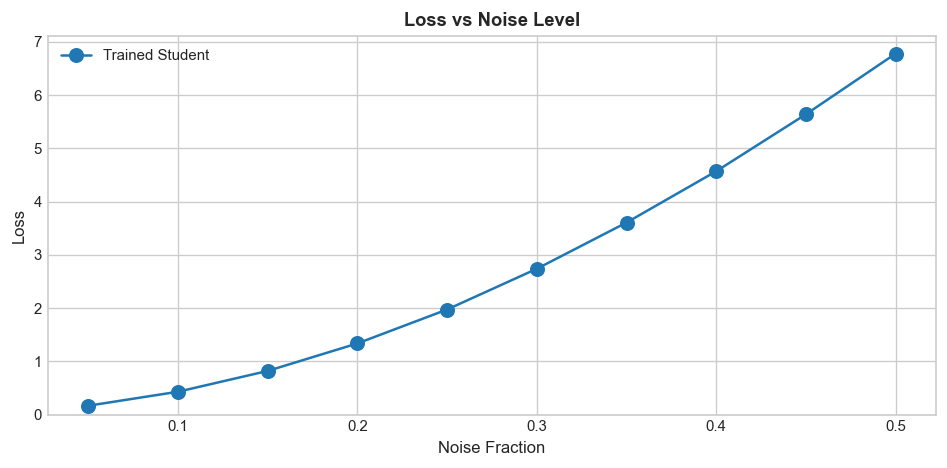

In [18]:
if not HAS_VARYING_NOISE:
    print("SKIPPED: no varying-noise data")
else:
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(
        results_df["noise_fraction"],
        results_df["final_loss"],
        "o-",
        color="C0",
        markersize=8,
        label="Trained Student",
    )
    if HAS_INFERENCE_NOISE:
        ax.plot(
            inference_df["noise_fraction"],
            inference_df["inference_loss"],
            "^:",
            color="C2",
            markersize=8,
            label="Correct Student",
        )

    ax.set_xlabel("Noise Fraction")
    ax.set_ylabel("Loss")
    ax.set_title("Loss vs Noise Level", fontweight="bold")
    ax.set_ylim(0, None)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

In [19]:
if not HAS_VARYING_NOISE:
    print("SKIPPED: no varying-noise data")
else:
    print("Increasing Noise Summary:")
    print("=" * 90)

    if HAS_INFERENCE_NOISE:
        merged = results_df.merge(inference_df, on="noise_fraction", how="inner")
        print(
            f"\n{'Noise':>6} {'Loss (TS)':>11} {'Loss (CS)':>11} {'FR Exc (TS)':>13} {'FR Exc (T)':>12} {'FR Exc (CS)':>13}"
        )
        print("-" * 82)
        for _, row in merged.iterrows():
            print(
                f"{row['noise_fraction']:>6.2f} {row['final_loss']:>11.4f} {row['inference_loss']:>11.4f} "
                f"{row['student_fr_exc']:>13.2f} {row['teacher_fr_exc']:>12.2f} {row['inference_fr_exc']:>13.2f}"
            )
        print(
            "\n(TS) = Trained Student, (T) = Teacher, (CS) = Correct Student (SF at target)"
        )
    else:
        print(
            f"\n{'Noise':>6} {'Loss (TS)':>11} {'FR Exc (TS)':>13} {'FR Exc (T)':>12}"
        )
        print("-" * 50)
        for _, row in results_df.iterrows():
            print(
                f"{row['noise_fraction']:>6.2f} {row['final_loss']:>11.4f} {row['student_fr_exc']:>13.2f} {row['teacher_fr_exc']:>12.2f}"
            )
        print("\n(TS) = Trained Student, (T) = Teacher")

Increasing Noise Summary:

 Noise   Loss (TS)   FR Exc (TS)   FR Exc (T)
--------------------------------------------------
  0.05      0.1648          2.46         2.41
  0.10      0.4276          2.47         2.41
  0.15      0.8182          2.47         2.41
  0.20      1.3347          2.47         2.41
  0.25      1.9718          2.46         2.41
  0.30      2.7365          2.45         2.41
  0.35      3.6046          2.44         2.41
  0.40      4.5687          2.42         2.41
  0.45      5.6383          2.40         2.41
  0.50      6.7779          2.39         2.41

(TS) = Trained Student, (T) = Teacher


### Spike Train & Firing Rate Comparison Across Noise Levels

In [ ]:
if not HAS_VARYING_NOISE:
    print("SKIPPED: no varying-noise data")
else:
    N_RASTER = 10
    noise_levels = sorted(results_df["noise_fraction"].tolist())

    for noise in noise_levels:
        trained_path = (
            varying_noise_dir / f"noise-{noise:.2f}" / "final_state" / "plot_data.npz"
        )

        if not trained_path.exists():
            print(f"Skipping noise={noise:.2f}: missing plot_data.npz")
            continue

        td = np.load(trained_path)
        teacher_sp = td["teacher_spikes"]
        student_sp = td["student_spikes"]
        dt_val = float(td["dt"])
        n_total = teacher_sp.shape[1]
        n_raster = min(N_RASTER, n_total)

        n_5s = int(5000.0 / dt_val)
        teacher_sp_r = teacher_sp[:n_5s, :n_raster]
        student_sp_r = student_sp[:n_5s, :n_raster]

        interleaved, ct_idx = interleave_spike_trains(
            teacher_sp_r, student_sp_r, n_neurons=n_raster
        )

        fig = plot_spike_trains(
            spikes=interleaved,
            dt=dt_val,
            cell_type_indices=ct_idx,
            cell_type_names=["Teacher", "Trained Student"],
            n_neurons_plot=2 * n_raster,
            n_compared=2,
            fraction=1.0,
            random_seed=None,
            title=f"Spike Raster \u2014 Noise = {noise:.2f} ({n_raster}/{n_total} neurons)",
            ylabel="Neuron",
            figsize=(16, 8),
        )
        plt.tight_layout()
        if noise == 0.4:
            plt.show()

In [ ]:
if not HAS_VARYING_NOISE:
    print("SKIPPED: no varying-noise data")
else:
    noise_levels = sorted(results_df["noise_fraction"].tolist())

    all_fr_data = {}
    for noise in noise_levels:
        trained_path = (
            varying_noise_dir / f"noise-{noise:.2f}" / "final_state" / "plot_data.npz"
        )
        if not trained_path.exists():
            continue

        td = np.load(trained_path)
        dt_val = float(td["dt"])
        ct = td["cell_type_indices"]

        teacher_fr = firing_rates_from_spikes(td["teacher_spikes"], dt_val)
        student_fr = firing_rates_from_spikes(td["student_spikes"], dt_val)
        all_fr_data[noise] = (teacher_fr, student_fr, ct)

    max_rate = 40
    r2_student_list = []
    r2_noise_list = []

    for noise in noise_levels:
        if noise not in all_fr_data:
            print(f"Skipping noise={noise:.2f}: missing data")
            continue

        teacher_fr, student_fr, ct = all_fr_data[noise]
        r2_val = r_squared(teacher_fr, student_fr)
        r2_noise_list.append(noise)
        r2_student_list.append(r2_val)

        fig = plot_firing_rate_scatter(
            teacher_fr,
            student_fr,
            ct,
            split_panels=True,
            max_rate=max_rate,
            figsize=(10, 5),
        )
        fig.suptitle(f"Noise = {noise:.2f}", fontweight="bold")
        plt.tight_layout()
        if noise == 0.4:
            plt.show()

In [ ]:
if not HAS_VARYING_NOISE:
    print("SKIPPED: no varying-noise data")
else:
    from connectome_snns.visualization.firing_rate_scatter import plot_r2_vs_parameter

    plot_r2_vs_parameter(
        r2_noise_list,
        {"Trained Student": r2_student_list},
        xlabel="Noise Fraction",
        title="Firing Rate R\u00b2 vs Noise Level",
    )
    plt.show()

### Spike Train Fluctuation Matching (Gaussian-Smoothed R²)

Measures how well the trained student matches the *temporal fluctuations* of the teacher. Each neuron's spike train is convolved with a Gaussian kernel (σ = 50 ms), and R² is computed across all neurons and time points.

In [ ]:
if not HAS_VARYING_NOISE:
    print("SKIPPED: no varying-noise data")
else:
    TAU_MS = 50.0  # Gaussian kernel std in ms

    noise_levels = sorted(results_df["noise_fraction"].tolist())
    r2_fluct_noise_list = []
    r2_fluct_student_list = []

    for noise in noise_levels:
        trained_path = (
            varying_noise_dir / f"noise-{noise:.2f}" / "final_state" / "plot_data.npz"
        )
        cache_path = varying_noise_dir / f"noise-{noise:.2f}" / "fluct_r2.npz"

        if not trained_path.exists():
            print(f"Skipping noise={noise:.2f}: missing plot_data.npz")
            continue

        if cache_path.exists():
            cached = np.load(cache_path)
            r2 = float(cached["r2_fluct"])
            print(f"noise={noise:.2f}  R\u00b2={r2:.4f}  (cached)")
        else:
            td = np.load(trained_path)
            dt_val = float(td["dt"])
            teacher_sp = td["teacher_spikes"].astype(np.float32)
            student_sp = td["student_spikes"].astype(np.float32)

            r2 = fluctuation_r_squared(teacher_sp, student_sp, TAU_MS, dt_val)

            np.savez(cache_path, r2_fluct=r2)
            sigma = TAU_MS / dt_val
            print(
                f"noise={noise:.2f}  R\u00b2={r2:.4f}  (sigma={sigma:.1f} steps, dt={dt_val} ms)"
            )

        r2_fluct_noise_list.append(noise)
        r2_fluct_student_list.append(r2)

    print(f"\nGaussian kernel: tau={TAU_MS:.0f} ms")

In [ ]:
if not HAS_VARYING_NOISE:
    print("SKIPPED: no varying-noise data")
else:
    from connectome_snns.visualization.firing_rate_scatter import plot_r2_vs_parameter

    plot_r2_vs_parameter(
        r2_fluct_noise_list,
        {"Trained Student": r2_fluct_student_list},
        xlabel="Noise Fraction",
        title=f"Spike Train Fluctuation R\u00b2 vs Noise Level (Gaussian \u03c3 = {TAU_MS:.0f} ms)",
    )
    plt.show()